# 3MD3220: Reinforcement Learning — Individual Assignment
## Text Flappy Bird: Monte Carlo vs Sarsa(λ)

**Student:** Côme Genet  
**Date:** 27 March 2026  

---

### Structure
1. Installation
2. Imports & reproducibility
3. Environment wrapper and state discretization
4. Agent 1: On-Policy First-Visit Monte Carlo
5. Agent 2: Sarsa(λ) with replacing traces
6. Training loops
7. Learning curves
8. State-value function visualization
9. Greedy policy visualization
10. Evaluation of trained agents (greedy, ε=0)
11. Parameter sweeps
12. Generalization across environment configurations
13. Discussion: can these agents be used on the original Flappy Bird gym?

## 1. Installation

The `text-flappy-bird-gym` package must be installed from the CentraleSupélec GitLab.  
Run the cell below once in Colab.

In [49]:
# Install from GitLab (Colab / first run)
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "git+https://gitlab-research.centralesupelec.fr/"
     "stergios.christodoulidis/text-flappy-bird-gym.git",
     "--quiet"],
    capture_output=True, text=True
)
print(result.stdout or "Installation OK")
if result.returncode != 0:
    print("STDERR:", result.stderr)

Installation OK


## 2. Imports & reproducibility

In [50]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from itertools import product
import gymnasium as gym
import text_flappy_bird_gym  # registers envs
import warnings, random, time
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Matplotlib style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("All imports OK")

All imports OK


## 3. Environment wrapper & state discretization

We use `TextFlappyBird-v0`, which returns a 2D continuous observation  
`(dx, dy)` representing the distance of the player from the center of the  
closest upcoming pipe gap. The action space is binary: `0` (do nothing) or `1` (flap).

To apply tabular RL methods, we discretize both axes into uniform bins.

In [51]:
class DiscretizedTFB:
    """
    Thin wrapper around TextFlappyBird-v0 that:
    - discretizes the (dx, dy) observation into integer bins
    - exposes step(), reset(), render() with the same interface
    - tracks per-episode scores
    """

    def __init__(
        self,
        height: int = 15,
        width: int = 20,
        pipe_gap: int = 4,
        n_bins_x: int = 20,
        n_bins_y: int = 20,
        seed: int = SEED,
    ):
        self.env = gym.make(
            "TextFlappyBird-v0",
            height=height,
            width=width,
            pipe_gap=pipe_gap,
        )
        self.n_bins_x = n_bins_x
        self.n_bins_y = n_bins_y
        # Observation bounds: dx in [0, width], dy in [-height, height]
        self.x_bins = np.linspace(0, width, n_bins_x + 1)
        self.y_bins = np.linspace(-height, height, n_bins_y + 1)
        self.n_states = n_bins_x * n_bins_y
        self.n_actions = 2
        # Seed the env once at instantiation, not at every reset
        self.env.reset(seed=seed)

    def _discretize(self, obs) -> tuple:
        dx, dy = obs[0], obs[1]
        bx = int(np.clip(np.digitize(dx, self.x_bins) - 1, 0, self.n_bins_x - 1))
        by = int(np.clip(np.digitize(dy, self.y_bins) - 1, 0, self.n_bins_y - 1))
        return (bx, by)

    def reset(self):
        # No seed here: each episode starts from a genuinely new random state
        obs, _ = self.env.reset()
        return self._discretize(obs)

    def step(self, action: int):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return self._discretize(obs), reward, done, info

    @property
    def state_shape(self):
        return (self.n_bins_x, self.n_bins_y)


# Quick sanity check
env_test = DiscretizedTFB()
s = env_test.reset()
s2, r, done, info = env_test.step(0)
print(f"Initial state: {s}  |  Next state: {s2}  |  Reward: {r}  |  Done: {done}")
print(f"State space size: {env_test.n_states}  |  Actions: {env_test.n_actions}")

Initial state: (13, 12)  |  Next state: (12, 12)  |  Reward: 1  |  Done: False
State space size: 400  |  Actions: 2


## 4. Agent 1: On-Policy First-Visit Monte Carlo (ε-greedy)

**Algorithm:** On-policy first-visit MC control (Sutton & Barto, chap. 5.4).  
We maintain a Q-table `Q[s, a]` and update it at the end of each episode using  
the average of the first-visit returns. The policy is ε-greedy with exponential decay.

In [52]:
class MonteCarloAgent:
    """
    On-policy first-visit Monte Carlo control with ε-greedy policy.
    Q-table indexed as Q[bx, by, action].
    """

    def __init__(
        self,
        state_shape: tuple,
        n_actions: int = 2,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.995,
    ):
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.n_actions = n_actions

        shape = state_shape + (n_actions,)
        self.Q = np.zeros(shape)
        self.returns_sum = np.zeros(shape)
        self.returns_count = np.zeros(shape)

    def select_action(self, state: tuple) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, episode: list):
        """
        episode: list of (state, action, reward) tuples.
        First-visit MC: only update Q the first time (s, a) appears.
        """
        G = 0.0
        visited = set()
        for state, action, reward in reversed(episode):
            G = self.gamma * G + reward
            sa = (state, action)
            if sa not in visited:
                visited.add(sa)
                idx = state + (action,)
                self.returns_sum[idx] += G
                self.returns_count[idx] += 1
                self.Q[idx] = self.returns_sum[idx] / self.returns_count[idx]

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def get_value_function(self) -> np.ndarray:
        """V(s) = max_a Q(s, a)."""
        return np.max(self.Q, axis=-1)


print("MonteCarloAgent defined.")

MonteCarloAgent defined.


## 5. Agent 2: Sarsa(λ) with replacing eligibility traces

**Algorithm:** Sarsa(λ) as described in Sutton & Barto, section 12.7.  
We use **replacing traces**: `e[s, a] = 1` on visit (rather than accumulating),  
which improves stability. The trace decays by `γλ` at each step.

In [53]:
class SarsaLambdaAgent:
    """
    Tabular Sarsa(λ) with replacing eligibility traces and ε-greedy policy.
    Q-table indexed as Q[bx, by, action].
    """

    def __init__(
        self,
        state_shape: tuple,
        n_actions: int = 2,
        alpha: float = 0.1,
        gamma: float = 0.99,
        lam: float = 0.8,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.995,
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.n_actions = n_actions

        shape = state_shape + (n_actions,)
        self.Q = np.zeros(shape)
        self.e = np.zeros(shape)   # eligibility traces

    def select_action(self, state: tuple) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def reset_traces(self):
        self.e[:] = 0.0

    def step_update(self, state, action, reward, next_state, next_action, done=False):
        """
        Single Sarsa(λ) update step (called online, at each transition).
        When done=True, no bootstrap on next_state (terminal state has no value).
        """
        if done:
            # Terminal transition: target is reward only, no bootstrapping
            delta = reward - self.Q[state + (action,)]
        else:
            delta = (
                reward
                + self.gamma * self.Q[next_state + (next_action,)]
                - self.Q[state + (action,)]
            )
        # Replacing traces: set visited state-action to 1
        self.e[state + (action,)] = 1.0
        # Update all Q values proportional to their trace
        self.Q += self.alpha * delta * self.e
        # Decay traces
        self.e *= self.gamma * self.lam

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def get_value_function(self) -> np.ndarray:
        return np.max(self.Q, axis=-1)


print("SarsaLambdaAgent defined.")

SarsaLambdaAgent defined.


## 6. Training loops

In [54]:
def train_mc(
    env: DiscretizedTFB,
    agent: MonteCarloAgent,
    n_episodes: int = 5000,
    max_steps: int = 2000,
    verbose_every: int = 500,
):
    """
    Monte Carlo training loop.
    Returns lists of total_rewards and scores per episode.
    """
    rewards_history = []
    scores_history  = []

    for ep in range(n_episodes):
        state = env.reset()
        episode = []
        total_reward = 0.0

        for _ in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            episode.append((state, action, reward))
            total_reward += reward
            state = next_state
            if done:
                break

        agent.update(episode)
        agent.decay_epsilon()
        rewards_history.append(total_reward)
        scores_history.append(info.get("score", 0))

        if (ep + 1) % verbose_every == 0:
            avg_r = np.mean(rewards_history[-verbose_every:])
            avg_s = np.mean(scores_history[-verbose_every:])
            print(f"  [MC]  Ep {ep+1:5d} | ε={agent.epsilon:.3f} "
                  f"| AvgReward={avg_r:7.2f} | AvgScore={avg_s:.2f}")

    return rewards_history, scores_history


def train_sarsa(
    env: DiscretizedTFB,
    agent: SarsaLambdaAgent,
    n_episodes: int = 5000,
    max_steps: int = 2000,
    verbose_every: int = 500,
):
    """
    Sarsa(λ) online training loop.
    Returns lists of total_rewards and scores per episode.
    """
    rewards_history = []
    scores_history  = []

    for ep in range(n_episodes):
        state  = env.reset()
        action = agent.select_action(state)
        agent.reset_traces()
        total_reward = 0.0

        for _ in range(max_steps):
            next_state, reward, done, info = env.step(action)
            next_action = agent.select_action(next_state)
            # Pass done so the update skips bootstrapping on terminal states
            agent.step_update(state, action, reward, next_state, next_action, done=done)
            total_reward += reward
            state  = next_state
            action = next_action
            if done:
                # Clear traces at end of episode before next episode starts
                agent.reset_traces()
                break

        agent.decay_epsilon()
        rewards_history.append(total_reward)
        scores_history.append(info.get("score", 0))

        if (ep + 1) % verbose_every == 0:
            avg_r = np.mean(rewards_history[-verbose_every:])
            avg_s = np.mean(scores_history[-verbose_every:])
            print(f"  [Sλ]  Ep {ep+1:5d} | ε={agent.epsilon:.3f} "
                  f"| AvgReward={avg_r:7.2f} | AvgScore={avg_s:.2f}")

    return rewards_history, scores_history


print("Training loops defined.")

Training loops defined.


In [55]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
ENV_CONFIG = dict(height=15, width=20, pipe_gap=4, n_bins_x=20, n_bins_y=20)
N_EPISODES  = 6000
GAMMA       = 0.99
EPS_START   = 1.0
EPS_END     = 0.01
EPS_DECAY   = 0.9985

# ── Instantiate environments and agents ─────────────────────────────────────
env_mc = DiscretizedTFB(**ENV_CONFIG)
env_sl = DiscretizedTFB(**ENV_CONFIG)

mc_agent = MonteCarloAgent(
    state_shape=env_mc.state_shape,
    gamma=GAMMA,
    epsilon_start=EPS_START,
    epsilon_end=EPS_END,
    epsilon_decay=EPS_DECAY,
)

sl_agent = SarsaLambdaAgent(
    state_shape=env_sl.state_shape,
    alpha=0.1,
    gamma=GAMMA,
    lam=0.8,
    epsilon_start=EPS_START,
    epsilon_end=EPS_END,
    epsilon_decay=EPS_DECAY,
)

# ── Train ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Training Monte Carlo agent...")
t0 = time.time()
mc_rewards, mc_scores = train_mc(env_mc, mc_agent, n_episodes=N_EPISODES)
print(f"Done in {time.time()-t0:.1f}s")

print("=" * 60)
print("Training Sarsa(λ) agent...")
t0 = time.time()
sl_rewards, sl_scores = train_sarsa(env_sl, sl_agent, n_episodes=N_EPISODES)
print(f"Done in {time.time()-t0:.1f}s")

Training Monte Carlo agent...
  [MC]  Ep   500 | ε=0.472 | AvgReward=  16.74 | AvgScore=0.57
  [MC]  Ep  1000 | ε=0.223 | AvgReward=  31.99 | AvgScore=2.02
  [MC]  Ep  1500 | ε=0.105 | AvgReward=  52.19 | AvgScore=4.08
  [MC]  Ep  2000 | ε=0.050 | AvgReward=  86.39 | AvgScore=7.59
  [MC]  Ep  2500 | ε=0.023 | AvgReward= 172.87 | AvgScore=16.20
  [MC]  Ep  3000 | ε=0.011 | AvgReward= 180.81 | AvgScore=17.06
  [MC]  Ep  3500 | ε=0.010 | AvgReward= 193.11 | AvgScore=18.29
  [MC]  Ep  4000 | ε=0.010 | AvgReward= 230.68 | AvgScore=22.05
  [MC]  Ep  4500 | ε=0.010 | AvgReward= 203.02 | AvgScore=19.29
  [MC]  Ep  5000 | ε=0.010 | AvgReward= 236.98 | AvgScore=22.75
  [MC]  Ep  5500 | ε=0.010 | AvgReward= 252.05 | AvgScore=24.20
  [MC]  Ep  6000 | ε=0.010 | AvgReward= 226.16 | AvgScore=21.57
Done in 13.0s
Training Sarsa(λ) agent...
  [Sλ]  Ep   500 | ε=0.472 | AvgReward=  15.49 | AvgScore=0.49
  [Sλ]  Ep  1000 | ε=0.223 | AvgReward=  37.38 | AvgScore=2.54
  [Sλ]  Ep  1500 | ε=0.105 | AvgReward=

## 7. Learning curves

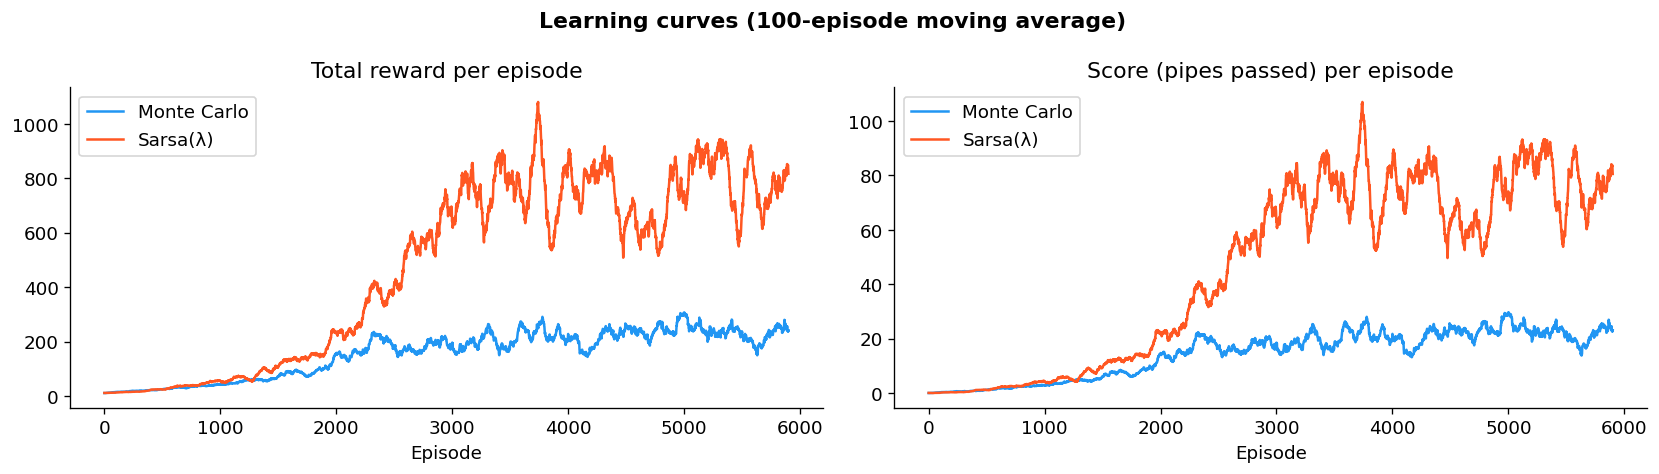

In [56]:
def smooth(x, w=100):
    """Moving average with window w."""
    return np.convolve(x, np.ones(w) / w, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, r_mc, r_sl, title in [
    (axes[0], mc_rewards, sl_rewards, "Total reward per episode"),
    (axes[1], mc_scores,  sl_scores,  "Score (pipes passed) per episode"),
]:
    ax.plot(smooth(r_mc), label="Monte Carlo", color="#2196F3", lw=1.5)
    ax.plot(smooth(r_sl), label="Sarsa(λ)",    color="#FF5722", lw=1.5)
    ax.set_xlabel("Episode")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Learning curves (100-episode moving average)", fontweight="bold")
plt.tight_layout()
plt.savefig("learning_curves.pdf", bbox_inches="tight")
plt.show()

## 8. State-value function visualization

`V(s) = max_a Q(s, a)`. The x-axis represents the horizontal distance to the  
next pipe, the y-axis the vertical offset from the gap center.  
High values indicate states where the agent expects to survive longer.

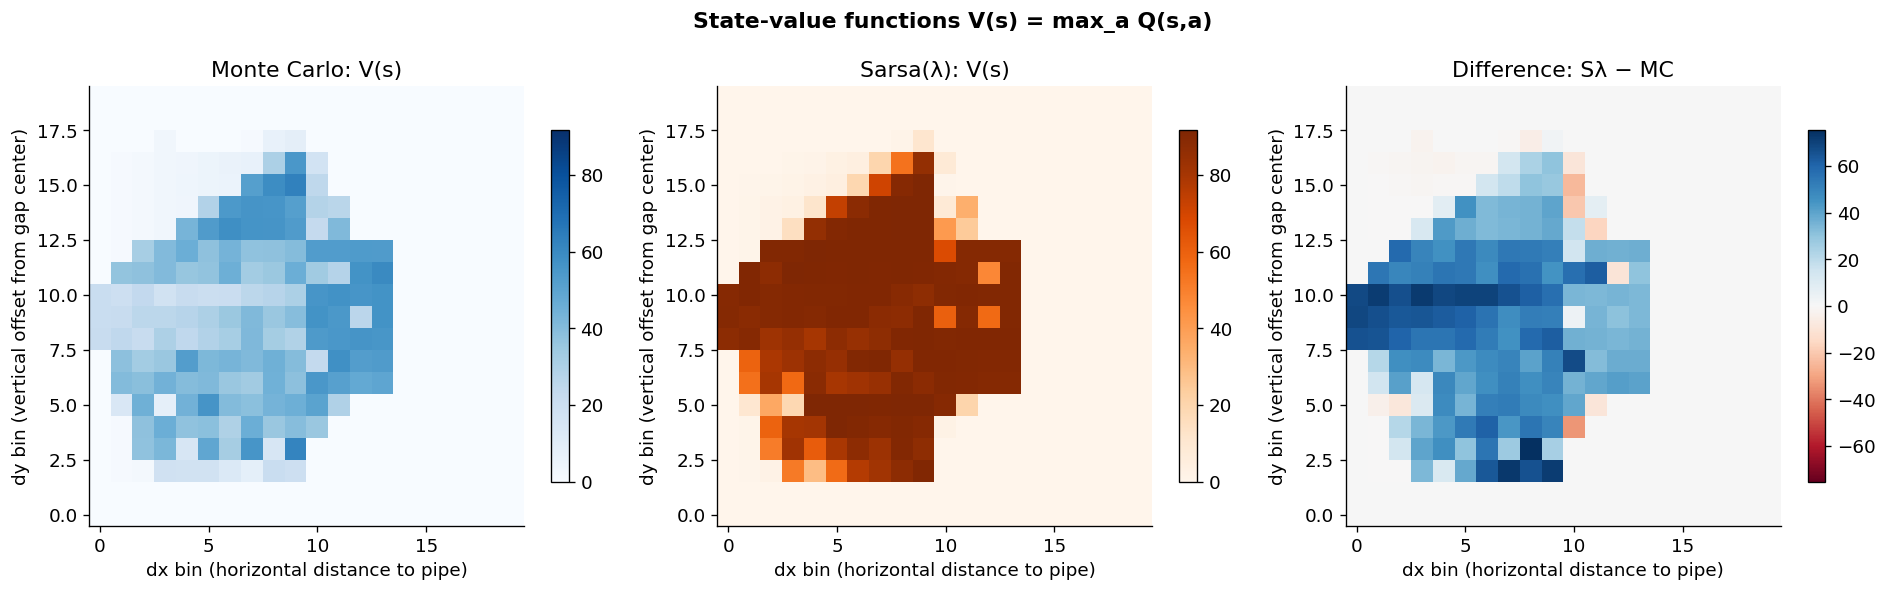

In [57]:
def plot_value_functions(mc_agent, sl_agent, env_config):
    V_mc = mc_agent.get_value_function()
    V_sl = sl_agent.get_value_function()

    n_bins_x = env_config["n_bins_x"]
    n_bins_y = env_config["n_bins_y"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    vmin = min(V_mc.min(), V_sl.min())
    vmax = max(V_mc.max(), V_sl.max())

    for ax, V, title, cmap in [
        (axes[0], V_mc, "Monte Carlo: V(s)",   "Blues"),
        (axes[1], V_sl, "Sarsa(λ): V(s)",       "Oranges"),
        (axes[2], V_sl - V_mc, "Difference: Sλ − MC", "RdBu"),
    ]:
        if "Diff" in title:
            im = ax.imshow(
                V.T, origin="lower", aspect="auto", cmap=cmap,
                vmin=-abs(V).max(), vmax=abs(V).max()
            )
        else:
            im = ax.imshow(
                V.T, origin="lower", aspect="auto", cmap=cmap,
                vmin=vmin, vmax=vmax
            )
        ax.set_xlabel("dx bin (horizontal distance to pipe)")
        ax.set_ylabel("dy bin (vertical offset from gap center)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle("State-value functions V(s) = max_a Q(s,a)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("value_functions.pdf", bbox_inches="tight")
    plt.show()


plot_value_functions(mc_agent, sl_agent, ENV_CONFIG)

## 9. Greedy policy visualization

We plot the greedy action `argmax_a Q(s, a)` across the state space.  
`0 = do nothing` (white), `1 = flap` (colored).

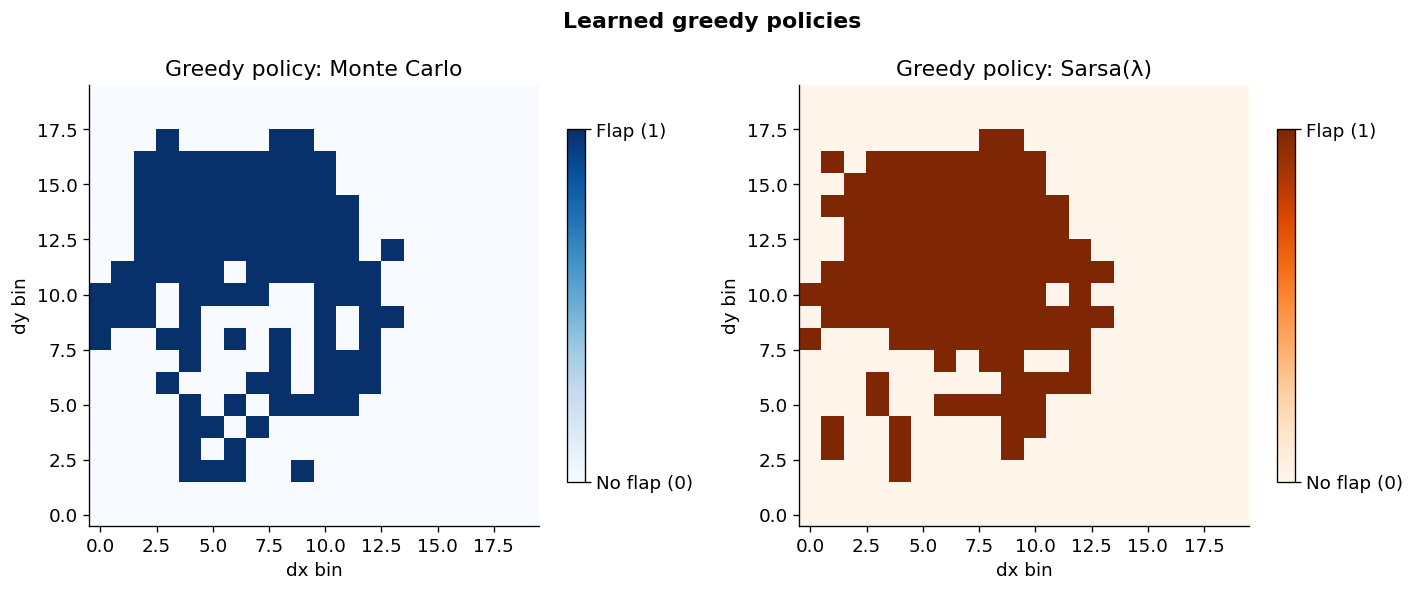

In [58]:
def plot_policies(mc_agent, sl_agent):
    P_mc = np.argmax(mc_agent.Q, axis=-1)
    P_sl = np.argmax(sl_agent.Q, axis=-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, P, title, color in [
        (axes[0], P_mc, "Greedy policy: Monte Carlo",  "Blues"),
        (axes[1], P_sl, "Greedy policy: Sarsa(λ)",     "Oranges"),
    ]:
        im = ax.imshow(P.T, origin="lower", aspect="auto", cmap=color, vmin=0, vmax=1)
        ax.set_xlabel("dx bin")
        ax.set_ylabel("dy bin")
        ax.set_title(title)
        cbar = plt.colorbar(im, ax=ax, ticks=[0, 1], shrink=0.8)
        cbar.set_ticklabels(["No flap (0)", "Flap (1)"])

    plt.suptitle("Learned greedy policies", fontweight="bold")
    plt.tight_layout()
    plt.savefig("policies.pdf", bbox_inches="tight")
    plt.show()


plot_policies(mc_agent, sl_agent)

## 10. Evaluation of trained agents (greedy, ε=0)

We run 200 greedy evaluation episodes and report mean/std of reward and score.

In [59]:
def evaluate_agent(env_config, Q, n_eval=200, max_steps=10000):
    """
    Greedy evaluation: ε=0, no training.
    Q: numpy array of shape (n_bins_x, n_bins_y, n_actions).
    """
    env = DiscretizedTFB(**env_config)
    rewards, scores = [], []
    for _ in range(n_eval):
        state = env.reset()
        total_r = 0.0
        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, r, done, info = env.step(action)
            total_r += r
            if done:
                break
        rewards.append(total_r)
        scores.append(info.get("score", 0))
    return np.array(rewards), np.array(scores)


mc_eval_r, mc_eval_s = evaluate_agent(ENV_CONFIG, mc_agent.Q)
sl_eval_r, sl_eval_s = evaluate_agent(ENV_CONFIG, sl_agent.Q)

print("Greedy evaluation over 200 episodes:")
print(f"  Monte Carlo  | Reward: {mc_eval_r.mean():.2f} ± {mc_eval_r.std():.2f} "
      f"| Score: {mc_eval_s.mean():.2f} ± {mc_eval_s.std():.2f}")
print(f"  Sarsa(λ)     | Reward: {sl_eval_r.mean():.2f} ± {sl_eval_r.std():.2f} "
      f"| Score: {sl_eval_s.mean():.2f} ± {sl_eval_s.std():.2f}")

Greedy evaluation over 200 episodes:
  Monte Carlo  | Reward: 960.56 ± 955.38 | Score: 95.30 ± 95.55
  Sarsa(λ)     | Reward: 4933.67 ± 3497.45 | Score: 492.13 ± 349.84


## 11. Parameter sweeps

### 11a. ε-decay sweep (both agents)

We vary the ε-decay rate and report the average score over the last 500 episodes.

  sweep ε-decay=0.9900
  sweep ε-decay=0.9925
  sweep ε-decay=0.9950
  sweep ε-decay=0.9975
  sweep ε-decay=0.9990


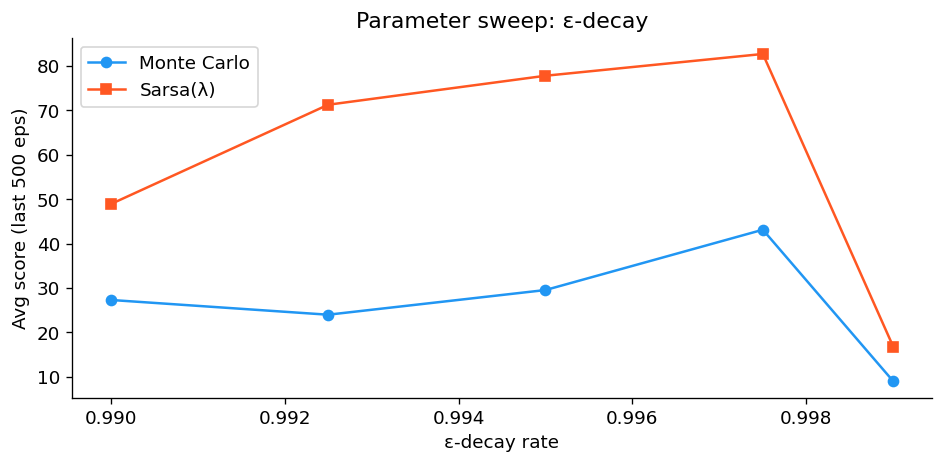

In [60]:
EPS_DECAYS  = [0.990, 0.9925, 0.995, 0.9975, 0.999]
N_EP_SWEEP  = 3000
WINDOW      = 500

mc_sweep_scores = []
sl_sweep_scores = []

for decay in EPS_DECAYS:
    print(f"  sweep ε-decay={decay:.4f}")

    env_ = DiscretizedTFB(**ENV_CONFIG)
    ag   = MonteCarloAgent(
        state_shape=env_.state_shape, epsilon_decay=decay,
        epsilon_start=1.0, epsilon_end=0.01, gamma=GAMMA
    )
    _, sc = train_mc(env_, ag, n_episodes=N_EP_SWEEP, verbose_every=9999)
    mc_sweep_scores.append(np.mean(sc[-WINDOW:]))

    env_ = DiscretizedTFB(**ENV_CONFIG)
    ag   = SarsaLambdaAgent(
        state_shape=env_.state_shape, epsilon_decay=decay,
        epsilon_start=1.0, epsilon_end=0.01,
        alpha=0.1, gamma=GAMMA, lam=0.8
    )
    _, sc = train_sarsa(env_, ag, n_episodes=N_EP_SWEEP, verbose_every=9999)
    sl_sweep_scores.append(np.mean(sc[-WINDOW:]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(EPS_DECAYS, mc_sweep_scores, "o-", label="Monte Carlo", color="#2196F3")
ax.plot(EPS_DECAYS, sl_sweep_scores, "s-", label="Sarsa(λ)",    color="#FF5722")
ax.set_xlabel("ε-decay rate")
ax.set_ylabel(f"Avg score (last {WINDOW} eps)")
ax.set_title("Parameter sweep: ε-decay")
ax.legend()
plt.tight_layout()
plt.savefig("sweep_epsilon.pdf", bbox_inches="tight")
plt.show()

### 11b. λ sweep (Sarsa(λ) only)

  sweep λ=0.00
  sweep λ=0.20
  sweep λ=0.40
  sweep λ=0.60
  sweep λ=0.80
  sweep λ=0.90
  sweep λ=0.95


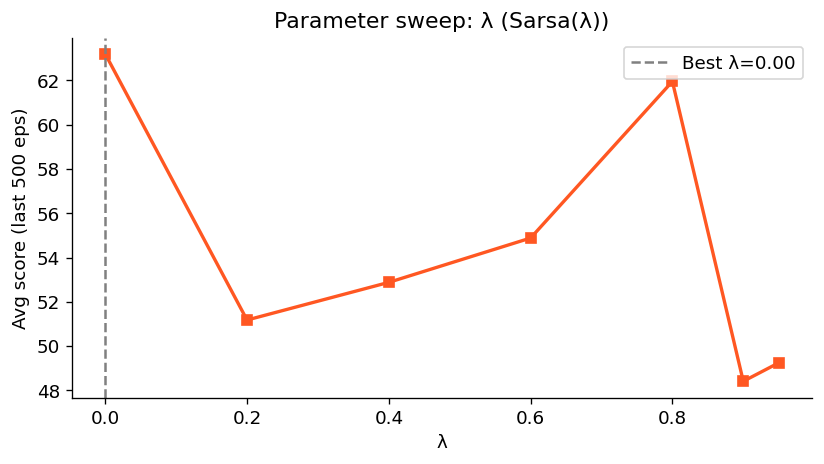

In [61]:
LAMBDAS = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

sl_lambda_scores = []

for lam in LAMBDAS:
    print(f"  sweep λ={lam:.2f}")
    env_ = DiscretizedTFB(**ENV_CONFIG)
    ag   = SarsaLambdaAgent(
        state_shape=env_.state_shape,
        alpha=0.1, gamma=GAMMA, lam=lam,
        epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9985
    )
    _, sc = train_sarsa(env_, ag, n_episodes=N_EP_SWEEP, verbose_every=9999)
    sl_lambda_scores.append(np.mean(sc[-WINDOW:]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(LAMBDAS, sl_lambda_scores, "s-", color="#FF5722", lw=2)
ax.set_xlabel("λ")
ax.set_ylabel(f"Avg score (last {WINDOW} eps)")
ax.set_title("Parameter sweep: λ (Sarsa(λ))")
ax.axvline(LAMBDAS[int(np.argmax(sl_lambda_scores))], ls="--",
           color="gray", label=f"Best λ={LAMBDAS[np.argmax(sl_lambda_scores)]:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("sweep_lambda.pdf", bbox_inches="tight")
plt.show()

### 11c. Learning rate α sweep (Sarsa(λ) only)

  sweep α=0.010
  sweep α=0.050
  sweep α=0.100
  sweep α=0.200
  sweep α=0.400


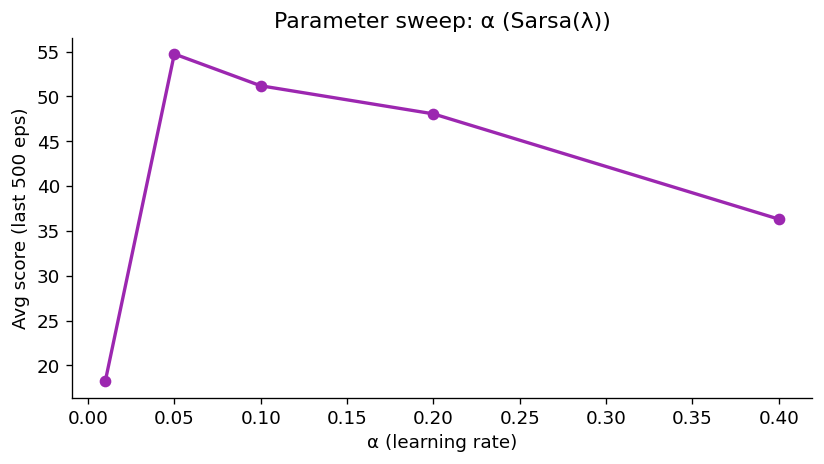

In [62]:
ALPHAS = [0.01, 0.05, 0.1, 0.2, 0.4]

sl_alpha_scores = []

for alpha in ALPHAS:
    print(f"  sweep α={alpha:.3f}")
    env_ = DiscretizedTFB(**ENV_CONFIG)
    ag   = SarsaLambdaAgent(
        state_shape=env_.state_shape,
        alpha=alpha, gamma=GAMMA, lam=0.8,
        epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9985
    )
    _, sc = train_sarsa(env_, ag, n_episodes=N_EP_SWEEP, verbose_every=9999)
    sl_alpha_scores.append(np.mean(sc[-WINDOW:]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ALPHAS, sl_alpha_scores, "o-", color="#9C27B0", lw=2)
ax.set_xlabel("α (learning rate)")
ax.set_ylabel(f"Avg score (last {WINDOW} eps)")
ax.set_title("Parameter sweep: α (Sarsa(λ))")
plt.tight_layout()
plt.savefig("sweep_alpha.pdf", bbox_inches="tight")
plt.show()

## 12. Generalization across environment configurations (Q4)

We train an agent on configuration A (`height=15, width=20, pipe_gap=4`)  
and evaluate it on configuration B (`height=20, width=25, pipe_gap=3`).  
We compare with a freshly trained agent on B.

Training fresh Sarsa(λ) on config B...

Generalization results (200 eval episodes on config B):
  MC trained on A, eval on B  | Score: 0.33 ± 0.84
  Sλ trained on A, eval on B  | Score: 1.92 ± 2.54
  Sλ trained on B, eval on B  | Score: 72.66 ± 74.90


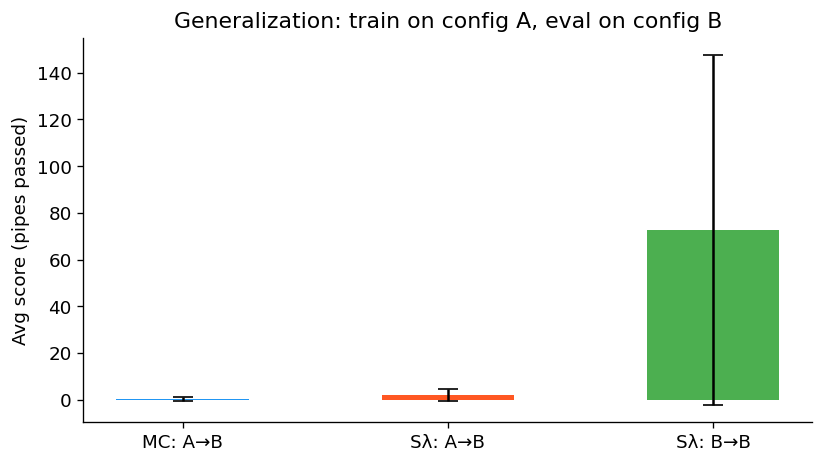

In [63]:
# Config B: different dimensions
ENV_CONFIG_B = dict(height=20, width=25, pipe_gap=3, n_bins_x=20, n_bins_y=20)

# Evaluate agent trained on A, on env B
mc_transfer_r, mc_transfer_s = evaluate_agent(ENV_CONFIG_B, mc_agent.Q)
sl_transfer_r, sl_transfer_s = evaluate_agent(ENV_CONFIG_B, sl_agent.Q)

# Train a fresh Sarsa(λ) agent on B
env_b = DiscretizedTFB(**ENV_CONFIG_B)
sl_b  = SarsaLambdaAgent(
    state_shape=env_b.state_shape, alpha=0.1, gamma=GAMMA, lam=0.8,
    epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9985
)
print("Training fresh Sarsa(λ) on config B...")
train_sarsa(env_b, sl_b, n_episodes=N_EPISODES, verbose_every=9999)
sl_b_r, sl_b_s = evaluate_agent(ENV_CONFIG_B, sl_b.Q)

print("\nGeneralization results (200 eval episodes on config B):")
print(f"  MC trained on A, eval on B  | Score: {mc_transfer_s.mean():.2f} ± {mc_transfer_s.std():.2f}")
print(f"  Sλ trained on A, eval on B  | Score: {sl_transfer_s.mean():.2f} ± {sl_transfer_s.std():.2f}")
print(f"  Sλ trained on B, eval on B  | Score: {sl_b_s.mean():.2f} ± {sl_b_s.std():.2f}")

# Bar chart
labels  = ["MC: A→B", "Sλ: A→B", "Sλ: B→B"]
means   = [mc_transfer_s.mean(), sl_transfer_s.mean(), sl_b_s.mean()]
stds    = [mc_transfer_s.std(),  sl_transfer_s.std(),  sl_b_s.std()]
colors  = ["#2196F3", "#FF5722", "#4CAF50"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, color=colors, capsize=6, width=0.5)
ax.set_ylabel("Avg score (pipes passed)")
ax.set_title("Generalization: train on config A, eval on config B")
plt.tight_layout()
plt.savefig("generalization.pdf", bbox_inches="tight")
plt.show()

## 13. Discussion: can these agents be used on the original Flappy Bird gym? (Q3)

The original `flappy-bird-gym` ([Talendar](https://github.com/Talendar/flappy-bird-gym))  
exposes either a raw RGB pixel observation (210×288×3) or a continuous vector  
of game features. Both are **continuous and high-dimensional**.  

Our agents rely on a **tabular Q-function** whose size is `n_bins_x × n_bins_y × n_actions`.  
Scaling this to a 210×288 pixel space or even a coarsely binned version of it would  
make the table intractably large and would require an exponential number of episodes  
to converge (the curse of dimensionality).  

A principled extension would require replacing the Q-table with a **function approximator**:
- For the feature-based observation: linear function approximation with tile coding, or a shallow MLP.
- For the pixel-based observation: a CNN encoder followed by DQN (Mnih et al., 2015).

In particular, Sarsa(λ) extends naturally to the semi-gradient setting  
(see Sutton & Barto, ch. 12), making it conceptually compatible with function approximation,  
while standard MC control does not extend as cleanly (no online update, no bootstrapping).

In [64]:
# Summary comparison table
import pandas as pd

summary = pd.DataFrame({
    "Agent":            ["Monte Carlo", "Sarsa(λ)"],
    "Update type":      ["End of episode", "Online (per step)"],
    "Bootstrap":        ["No", "Yes"],
    "Credit assignment":["Full return G", "Eligibility traces"],
    "Key hyperparams":  ["ε-decay, γ", "α, λ, ε-decay, γ"],
    "Extends to FA":    ["Partially (policy grad.)", "Yes (semi-gradient)"],
    "AvgScore (eval)":  [
        f"{mc_eval_s.mean():.2f} ± {mc_eval_s.std():.2f}",
        f"{sl_eval_s.mean():.2f} ± {sl_eval_s.std():.2f}"
    ]
})

print(summary.to_string(index=False))

      Agent       Update type Bootstrap  Credit assignment  Key hyperparams            Extends to FA AvgScore (eval)
Monte Carlo    End of episode        No      Full return G       ε-decay, γ Partially (policy grad.)   95.30 ± 95.55
   Sarsa(λ) Online (per step)       Yes Eligibility traces α, λ, ε-decay, γ      Yes (semi-gradient) 492.13 ± 349.84


---